<a href="https://colab.research.google.com/github/SofiaKakou/Customer_Churn_Prediction/blob/main/notebooks/11_bank_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Introduction
This notebook trains and evaluates ML Models for customer churn predictions.

Purpose:
- load the prepared test and training datasets
- train baseline model
- train advanced model
- evaluate model performance
- compare results
- select best performing model

# 2.Imports

In [1]:
# importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

#metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

import warnings
warnings.filterwarnings("ignore")


# 3.Load Dataset

In [2]:

# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Load the prepared datasets
base_path = "/content/drive/MyDrive/Thesis/Prepared Data/"

x_train = pd.read_csv(base_path + "bank_x_train.csv")
x_test = pd.read_csv(base_path + "bank_x_test.csv")
y_train = pd.read_csv(base_path + "bank_y_train.csv").values.ravel()
y_test = pd.read_csv(base_path + "bank_y_test.csv").values.ravel()

# 4.Baseline Model | Logistic Regression

Logistic Regression is used as the baseline model because it is simple, interpretable and commonly used for binary classification problems.

The baseline model provides a reference point for comparing mode advanced models.

In [4]:
# Initialize and train
log_model = LogisticRegression(max_iter=1000)

log_model.fit(x_train, y_train)

# Predictions
y_pred_log = log_model.predict(x_test)
y_prob_log = log_model.predict_proba(x_test)[:, 1]

In [5]:
# Evaluation
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



## Observations

- Overall the baseline model provides a useful reference point, but its low recall for churn indicates that further model refinment is necessary to achieve meeaningul predictive performance.



# 5.Advanced Models
Two advanced models are trained and compared: Random Forest & XGBoost

- Random Forest: combined multiple decison trees & it can capture non linear relationships/ is robust to outlers.
- XGBoost: is known for strong predictive performance and it commonly used in tabular ML problems.

# 5.1Random Forest Model

Used for capturing non linear relationships and is robust to noise.

In [6]:
# Initialize & Train
rf = RandomForestClassifier (
    random_state=42
)

rf.fit(x_train, y_train)

# Predictions
y_pred_rf = rf.predict(x_test)
y_prob_rf = rf.predict_proba(x_test)[:, 1]

In [7]:
# Evaluation
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



## Observations

The RF shows improved performance compared to the Logistic Regression.

- Higher overall accuracy and F1 Score
- Better Balance between precision and recall
- Improved ability to capture non linear relationships in the data

Random Forest is more effective at identifying churn patterns due to its structure and ability to model complex interactions between features.

# 5.2XGBoost Model

* Used due to its strong performance in structured data and ability to handle complex interactions

In [9]:
# Initialize & Train
xgb_model = xgb.XGBClassifier(
  eval_metric="logloss",
  random_state=42
)

xgb_model.fit(x_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(x_test)
y_prob_xgb = xgb_model.predict_proba(x_test)[:, 1]

In [12]:
# Evaluation
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1593
           1       0.68      0.48      0.56       407

    accuracy                           0.85      2000
   macro avg       0.78      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000



# 6.Model Evaluation & Comparison

Based on:
- Accuracy
- Precision
- Recall - churn cases identified
- F1-Score - balance between precision and recall
- ROC-AUC - ability to distinguish between churn and non churn customers

In [13]:
# Collecting model metrics
def evaluate_model(name, y_true, y_pred, y_prob):
  return {
      "Model": name,
      "Accuracy": accuracy_score(y_true, y_pred),
      "Precision": precision_score(y_true, y_pred),
      "Recall": recall_score(y_true, y_pred),
      "F1-Score": f1_score(y_true, y_pred),
      "ROC-AUC": roc_auc_score(y_true, y_prob)
  }

results = []

results.append(evaluate_model("Logistic Regression", y_test, y_pred_log, y_prob_log))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf))
results.append(evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb))

results_df = pd.DataFrame(results)

results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.808,0.589147,0.186732,0.283582,0.774756
1,Random Forest,0.864,0.782427,0.459459,0.578947,0.852218
2,XGBoost,0.849,0.682927,0.481572,0.564841,0.832834


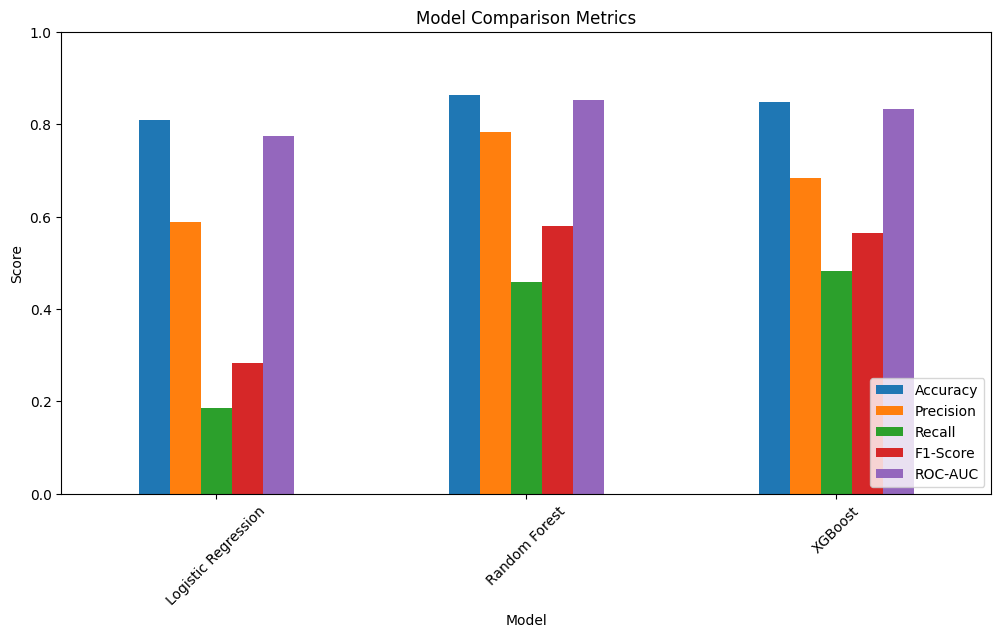

In [14]:
# Plot Model Comparison
results_df.set_index("Model")[["Accuracy",  "Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(kind="bar", figsize=(12, 6))

plt.title("Model Comparison Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.show()


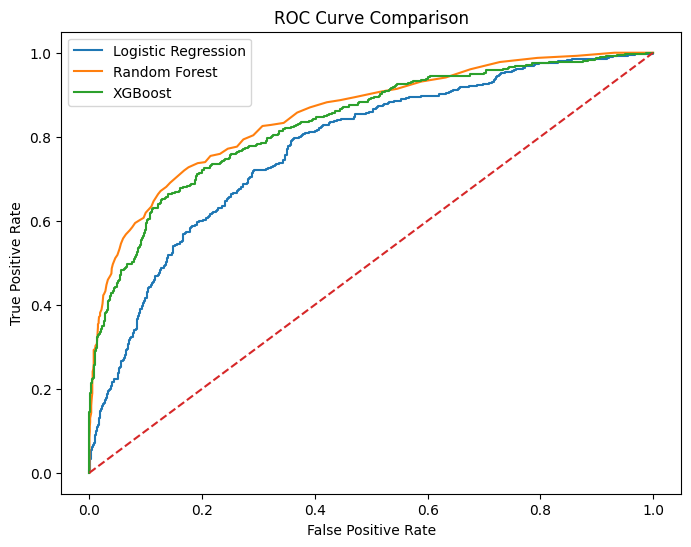

In [15]:
# ROC Curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Observations

The three models were compared using key evaluation metrics.

The comparison of models demonstrates that tree based methods significantly outperform the baseline logistic regression model in predicting customer churn. While logistic regression achieved reasonable overall accuracy, it failed to effectively identify churn case de to low recall.

Both RF and XGB showed substantial improvements across evaluation metrics, especially in recall and F1 score, indicating a better ability to detect churned customers. Among them, RF achieved the best overall balance.

# 7.Feature Importance
Feature importance helps identify which variables contribute most to model predictions.
This is useful for interpreting churn drivers and generating BI.

In [16]:
# Feature Importance (RF)
rf_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance.head(10)

,Feature,Importance
1,age,0.236485
7,estimated_salary,0.147016
0,credit_score,0.142756
3,balance,0.141756
4,products_number,0.130410
2,tenure,0.081817
6,active_member,0.039933
8,country_Germany,0.028923
5,credit_card,0.018799
10,gender_Male,0.018483


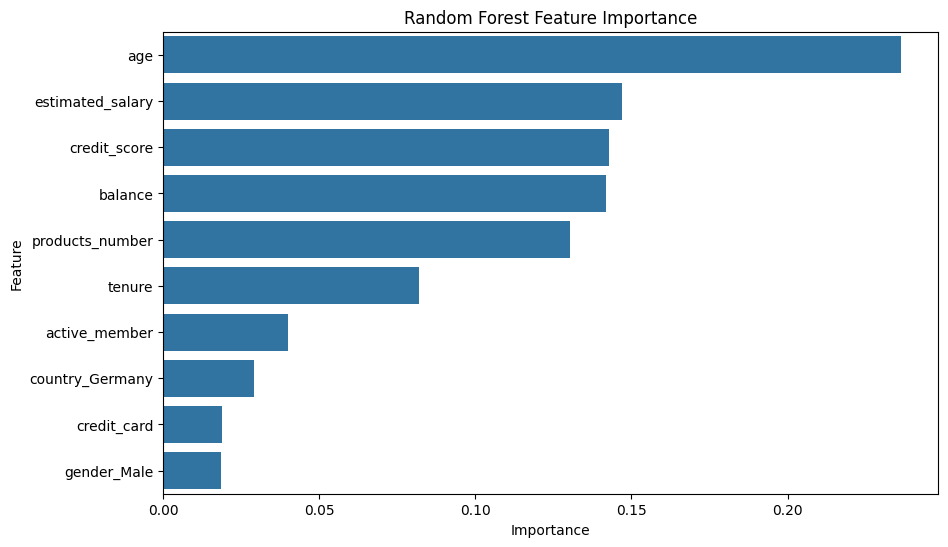

In [17]:
# Plot Feature Importance (RF)
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance", y="Feature", data=rf_importance.head(10))

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [19]:
# Feature Importance (XGBoost)

xgb_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance.head(10)

,Feature,Importance
4,products_number,0.300034
6,active_member,0.178280
1,age,0.124386
8,country_Germany,0.106436
3,balance,0.058472
10,gender_Male,0.046406
9,country_Spain,0.045115
7,estimated_salary,0.037887
0,credit_score,0.036877
2,tenure,0.033915


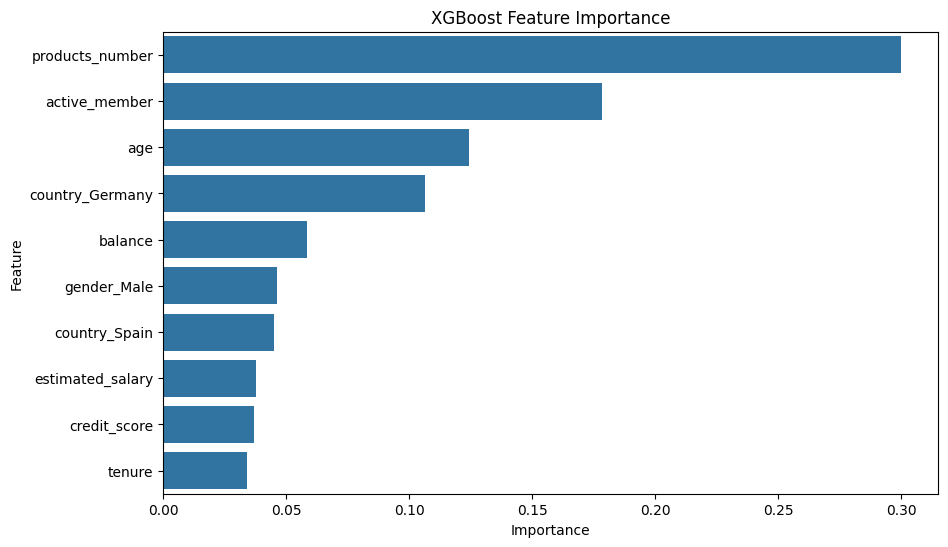

In [20]:
# Plot Feature Importance (XGBoost)
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance", y="Feature", data=xgb_importance.head(10))

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [21]:
# savings model outputs for future use

save_path = "/content/drive/MyDrive/Thesis/Prepared Data/"

results_df.to_csv(save_path + "bank_model_results.csv", index=False)
rf_importance.to_csv(save_path + "bank_rf_importance.csv", index=False)
xgb_importance.to_csv(save_path + "bank_xgb_importance.csv", index=False)

# 10.Conclusion

The analysis identified key factos infuelcing churn and particularly age, balance and customer activity. While the baseline logic regression model showed reasonable accuracy, it performed poorly in detecting churn.

In contrast RF and XGB significantly improved performance, confirming that churn prediction requires models capable of capturing non linear relationships. Overall, RF provided the best balance of rsults, making it the most suitable model for this task.